# **Ensemble learning**
Utilizar múltiples modelos o clasificadores **débiles** trabajando en conjunto con tal de obtener mejores resultados.
## ¿Qué entiendo por clasificador **débil**?
Estos son modelos cuyo desempeño es levemente mejor que simplemente clasificar de forma aleatoria, pero que suelen mantener una varianza baja...

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=14a033EHL371WMvHLGKQsRI7pUUvr2KrS" width="400"/>
</center>
</div>

El principio de esta estrategia yace en que el error de cada clasificador no está correlacionado entre clasificadores, por lo que la probabilidad de que todos los clasificadores cometan el mismo error es más baja que la del error generado por un solo clasificador monolítico.

## ¿Cómo decido el output final?

Cada clasificador me va a estar entregando una predicción y el objetivo es terminar con una (la de mi modelo ensamblado) y no finalizar presentando N predicciones. Para esto existen distintos criterios que se pueden seguir:

*    Voto mayoritario
*    Unanimidad
*    Pluralidad (escoger la clase que obtuvo la mayor cantidad de votos)
*    Asignar pesos para representar confianza en mi clasificador

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier

In [ ]:
#Importar datos
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [ ]:
csv_path = path +'/winequality-red.csv'

wine_df_og = pd.read_csv(csv_path, sep=',', on_bad_lines='skip')
wine_df = wine_df_og.copy()

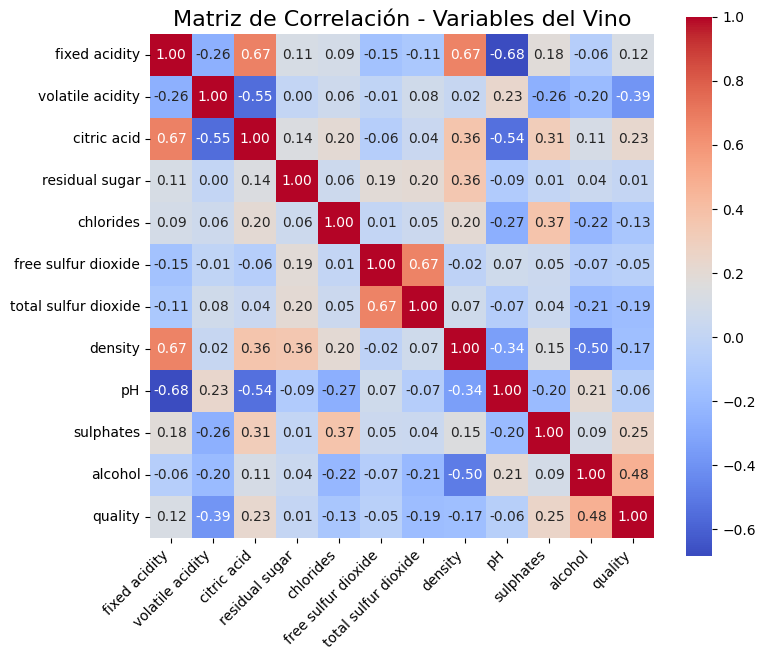

In [ ]:
# Este bloque tiene como fin ver las dimensiones que más inciden sobre la
# variable calidad.
correlation_matrix = wine_df.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .75})
plt.title("Matriz de Correlación - Variables del Vino", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Convertir los datos para ser trabajados como un problema de clasificación
# binaria: vino bueno (1) y vino malo (0).

wine_df['quality_categorical'] = pd.cut(
  wine_df['quality'],
  bins = [0, 5, 10],
  labels = [0, 1],
)

wine_df.drop('quality', axis=1, inplace=True)

display(wine_df.head())
display(wine_df.info())
display(wine_df["quality_categorical"].value_counts())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_categorical
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality_categorical   1599 non-null   category
dtypes: category(1), float64(11)
memory usage: 139.2 KB


None

,count
quality_categorical,
1,855
0,744


In [ ]:
# Se reducen las dimensiones del dataset de trabajo, dejando únicamente las
# dimensiones que más influyen en la calidad del vino. Además se truncan las
# mediciones para tener la misma representación de casos buenos que casos malos
# (744).

dataset_filtered = wine_df.filter(["alcohol", "sulphates", "citric acid", "quality_categorical"])
n = 744
bueno = dataset_filtered[dataset_filtered["quality_categorical"] == 1].sample(n)
malo = dataset_filtered[dataset_filtered["quality_categorical"] == 0].sample(n)

dataset = pd.concat([bueno, malo])

display(dataset.shape)
display(dataset["quality_categorical"].value_counts())

(1488, 4)

,count
quality_categorical,
0,744
1,744


In [ ]:
# Se separa el dataset en 70% entrenamiento y 30% prueba.
X = dataset.drop("quality_categorical", axis=1)
y = dataset["quality_categorical"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
  train_size=0.70,
  random_state=42,
  stratify=y
)


display(y_train.value_counts(normalize=True))
display(y_test.value_counts(normalize=True))

,proportion
quality_categorical,
1,0.50048
0,0.49952


,proportion
quality_categorical,
0,0.501119
1,0.498881


In [ ]:
# Se designan tres tipos de clasificadores débiles distintos, entrenados
# con los datos preparados previamente y evaluados mediante su área bajo
# la curva ROC.

clf1 = LogisticRegression(random_state=42)

clf2 = DecisionTreeClassifier(max_depth=1,
  criterion='entropy',
  random_state=42
)

clf3 = KNeighborsClassifier(n_neighbors=1,
  p=2,
  metric='minkowski'
)

classifier_names = ["R. Logística", "Decision Tree", "kNN"]
classifiers = [clf1, clf2, clf3]

for clf, clf_name  in zip(classifiers, classifier_names):
  results = cross_val_score(estimator=clf,
    X=X_train, y=y_train,
    scoring='roc_auc'
  )
  print(f'({clf_name}) - Métrica: ROC AUC = {results.mean():.2f} +/- {results.std():.2f}')

(R. Logística) - Métrica: ROC AUC = 0.76 +/- 0.04
(Decision Tree) - Métrica: ROC AUC = 0.68 +/- 0.03
(kNN) - Métrica: ROC AUC = 0.70 +/- 0.03


In [ ]:
# Proceso de ensamblaje de clasificadores simples. Se escoge un método
# de consenso "soft" que combina las probabilidades predichas por cada
# clasificador débil para cada clase y elige la clase con la mayor
# probabilidad promedio.

ensemble_clf = VotingClassifier(estimators=[
    ("RL", clf1), ("DT", clf2), ("kNN", clf3)
  ],
  voting='soft',
)

results = cross_val_score(estimator=ensemble_clf,
    X=X_train,
    y=y_train,
    cv=10,
    scoring='roc_auc'
)
print(f'Métrica: ROC AUC = {results.mean():.2f} +/- {results.std():.2f}')

Métrica: ROC AUC = 0.80 +/- 0.05


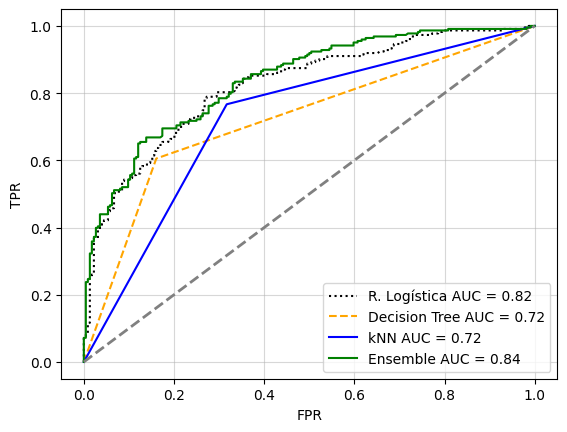

In [ ]:
colors = ["black", "orange", "blue", "green"]
line_styles = [":", "--", "-", "-"
]

classifier_names += ["Ensemble"]
classifiers += [ensemble_clf]

for clf, clf_name, color, ls in zip(classifiers, classifier_names, colors, line_styles):
  y_preds = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_preds)
  metric_roc_auc = roc_auc_score(y_test, y_preds)

  plt.plot(fpr, tpr, color=color, linestyle=ls, label=f"{clf_name} AUC = {metric_roc_auc:.2f}")

plt.legend(loc="lower right")
plt.xlabel("FPR")
plt.ylabel("TPR")

# Línea y = x
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth="2")
plt.grid(alpha=0.5)

plt.show()

# **Bagging**

Es entrenar mis clasificadores individuales **de forma paralela** en base a porciones de mi conjunto de entrenamiento escogidas al azar. Básicamente es hacer *bootstrap sampling*.<br>Esto lo hace una **herramienta muy útil para combatir la varianza**.<br><br>

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1BTI7MWnOw2AYGskixVSDxt57jI0SLcyd" width="400"/>
</center>
</div>

Existen dos tipos de bagging:

*    **Instance** Bagging: Sampling por filas. Se realiza remuestreo en base a las mediciones en mi dataframe.
*    **Feature** Bagging: Sampling por columnas. Se realiza remuestreo en base a las características en mi dataframe.

Voy a favorecer una subestrategia o la otra según el tipo de **desbalance** presente en mis datos. ¿Qué significa esto?

In [ ]:
wine_df_2 = wine_df_og.copy()
X = wine_df_2.drop("quality", axis=1)
y = wine_df_2["quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

dt_clf = DecisionTreeClassifier(criterion='entropy',
  random_state=1, max_depth=None,
)

# Instance Bagging
instance_bagging = BaggingClassifier(
    estimator=dt_clf,
    n_estimators=10,
    bootstrap=True,            # Instancias con reemplazo
    bootstrap_features=False,
    random_state=42
)

instance_bagging.fit(X_train, y_train)
y_pred = instance_bagging.predict(X_test)

print("Accuracy con Instance Bagging:", accuracy_score(y_test, y_pred))


Accuracy con Instance Bagging: 0.65


In [ ]:
# Feature Bagging
feature_bagging = BaggingClassifier(
    estimator=dt_clf,
    n_estimators=10,
    bootstrap=False,
    bootstrap_features=True,   # Características con reemplazo
    random_state=42
)

feature_bagging.fit(X_train, y_train)
y_pred = feature_bagging.predict(X_test)

print("Accuracy con Feature Bagging:", accuracy_score(y_test, y_pred))

Accuracy con Feature Bagging: 0.66


# Boosting

Si entendemos bagging como una técnica de clasificadores entrenados de forma paralela, boosting se refiere a un **entrenamiento secuencial**, orientado a trabajar o iterar sobre las predicciones débiles, erroneas o insuficientes, conformando un nuevo subconjunto de datos con el que se entrena el modelo siguiente en la cadena de clasificadores.

## Adaptative Boosting (AdaBoost)
<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1osBFtPfk0lQCtOLNeq-9MrHr_Vdjla8W" width="700"/>
</center>
</div>


In [ ]:
wine_df_3 = wine_df_og.copy()

# Clasificación binaria: calidad >= 7 como "alta calidad"
wine_df_3["high_quality"] = (wine_df_3["quality"] >= 7).astype(int)

X = wine_df_3.drop(["quality", "high_quality"], axis=1)
y = wine_df_3["high_quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

base_clf = DecisionTreeClassifier(max_depth=1)

# AdaBoost
ada_clf = AdaBoostClassifier(
    estimator=base_clf,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42)

ada_clf.fit(X_train, y_train)
y_pred = ada_clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.99      0.94       277
           1       0.79      0.35      0.48        43

    accuracy                           0.90       320
   macro avg       0.85      0.67      0.71       320
weighted avg       0.89      0.90      0.88       320



# **Stacking**

La idea fundamental ya se dio en la teoría: usar un modelo que realice la agregación misma de los clasificadores, en vez de votación por mayoría.

Un modelo (*meta-learner*) puede aprender esta mejor forma de combinar los resultados. Normalmente los modelos embebidos que utilizan *stacking* poseen varias capas.

La primera capa realiza las predicciones mediante los clasificadores débiles o *weak learners*. La última capa intenta ajustarse a las predicciones realizadas por la primera capa o las capas anteriores.

Un ejemplo para un modelo con una arquitectura de una capa sería:
1. Dividir el conjunto de entrenamiento en dos sets.
2. Se eligen 3 clasificadores para una primera capa. Entrenar 3 clasificadores con el primer conjunto separado.
3. Alimentar los modelos entrenados con el primer conjunto, con los datos del segundo conjunto que se había separado.
4. Es posible crear otro conjunto de entrenamiento usando los valores predichos por estos clasificadores, que serían 3 valores por cada dato.
  - De esta forma tendríamos otro nuevo conjunto $x_i = (p_1, p_2, p_3)$ **pero** se mantiene la etiqueta $y_i$ para alimentar a otro modelo.
  - Dicho de otra forma, el modelo anterior aprende, dadas las predicciones de los clasificadores de una primera capa, a predecir el valor objetivo (la clase, por ejemplo).


